<a href="https://colab.research.google.com/github/Adityabehl/ML_Learning/blob/main/Polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

CSV_PATH = list(uploaded.keys())[0]

print("Loaded file:", CSV_PATH)

Saving watermelon.csv to watermelon.csv
Loaded file: watermelon.csv


Dataset Preview:


,Country,Crop,Area,Unit,Season,Source,Code,Value_A,Value_B,Year,Value_C,Yield
0,India,Watermelon,All India,kg/ha,Annual,Practice dataset,1,1.000000,10.000000,2000,100.000000,14253.732803
1,India,Watermelon,All India,kg/ha,Annual,Practice dataset,2,1.038462,10.384615,2001,103.846154,15557.497150
2,India,Watermelon,All India,kg/ha,Annual,Practice dataset,3,1.076923,10.769231,2002,107.692308,15140.011224
3,India,Watermelon,All India,kg/ha,Annual,Practice dataset,4,1.115385,11.153846,2003,111.538462,15128.087153
4,India,Watermelon,All India,kg/ha,Annual,Practice dataset,5,1.153846,11.538462,2004,115.384615,16701.466054



Unique Areas:
['All India']

Total Unique Areas:
1
Linear Regression Coefficients:
[ 6.22106100e+02 -1.23009588e+06]

Polynomial Regression Coefficients:
[ 4.48525563e-01 -1.18365782e+03  5.87378291e+05]


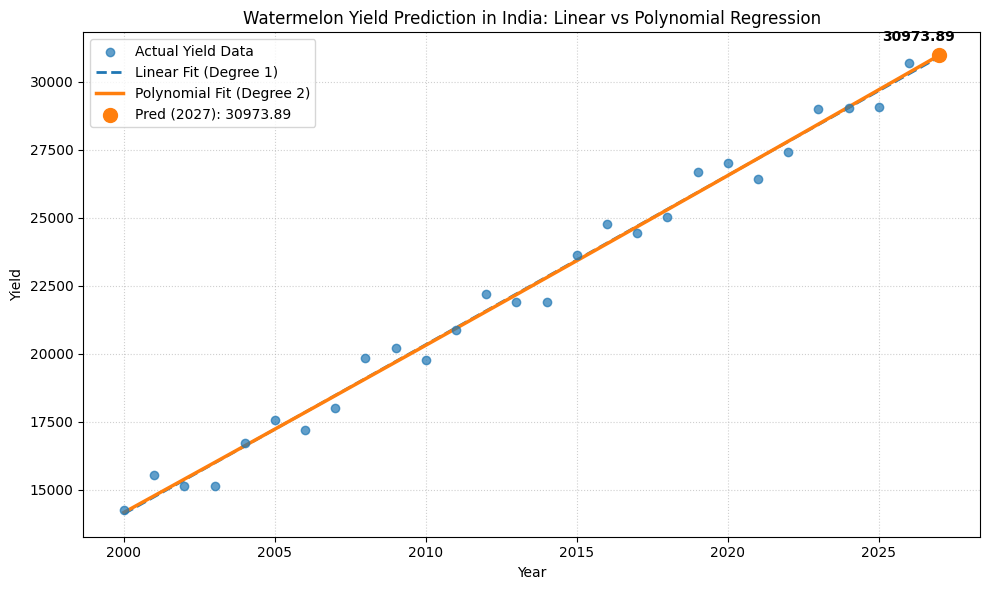

--- Actual vs Predicted Yield Comparison ---
 Year  Actual Yield  Linear Pred  Polynomial Pred
 2017  24456.026555   24692.1243     24672.090158
 2018  25026.464341   25314.2304     25298.232988
 2019  26699.568886   25936.3365     25925.272869
 2020  27015.254051   26558.4426     26553.209802
 2021  26440.679687   27180.5487     27182.043785
 2022  27427.642778   27802.6548     27811.774820
 2023  29001.170402   28424.7609     28442.402905
 2024  29038.275104   29046.8670     29073.928042
 2025  29055.669495   29668.9731     29706.350230
 2026  30699.776717   30291.0792     30339.669469

Predicted Yield for Year 2027 (Polynomial): 30973.89


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv(CSV_PATH)

print("Dataset Preview:")
display(df.head())

print("\nUnique Areas:")
print(df["Area"].unique())

print("\nTotal Unique Areas:")
print(df["Area"].nunique())


# ==========================================
# 2. SELECT YEAR AND YIELD
# ==========================================

# The dataset created earlier has Year and Yield columns

X = df["Year"].values
Y = df["Yield"].values


# ==========================================
# 3. CREATE POLYNOMIAL REGRESSION FUNCTIONS
# ==========================================

def fit_polynomial_regression(X, Y, degree):
    """
    Fits a polynomial regression model.

    degree=1 → Linear Regression
    degree=2 → Polynomial Regression
    """

    coefficients = np.polyfit(
        X,
        Y,
        degree
    )

    return coefficients


def predict_poly(X, coefficients):
    """
    Predict values using polynomial coefficients.
    """

    return np.polyval(
        coefficients,
        X
    )


# ==========================================
# 4. TRAIN BOTH MODELS
# ==========================================

# Linear Regression
beta_poly1 = fit_polynomial_regression(
    X,
    Y,
    degree=1
)

# Polynomial Regression
beta_poly2 = fit_polynomial_regression(
    X,
    Y,
    degree=2
)


# ==========================================
# 5. CREATE SMOOTH CURVES
# ==========================================

X_smooth = np.linspace(
    X.min(),
    X.max() + 1,
    300
)

Y_smooth_poly1 = predict_poly(
    X_smooth,
    beta_poly1
)

Y_smooth_poly2 = predict_poly(
    X_smooth,
    beta_poly2
)


# ==========================================
# 6. PREDICT NEXT YEAR
# ==========================================

next_year = np.array([
    X.max() + 1
])

pred_next_year = predict_poly(
    next_year,
    beta_poly2
)[0]


# ==========================================
# 7. DISPLAY MODEL EQUATIONS
# ==========================================

print("Linear Regression Coefficients:")
print(beta_poly1)

print("\nPolynomial Regression Coefficients:")
print(beta_poly2)


# ==========================================
# 8. VISUALIZATION
# ==========================================

plt.figure(
    figsize=(10, 6)
)


# Actual data points

plt.scatter(
    X,
    Y,
    alpha=0.7,
    label="Actual Yield Data",
    zorder=3
)


# Linear regression line

plt.plot(
    X_smooth,
    Y_smooth_poly1,
    linestyle="--",
    linewidth=2,
    label="Linear Fit (Degree 1)"
)


# Polynomial regression curve

plt.plot(
    X_smooth,
    Y_smooth_poly2,
    linewidth=2.5,
    label="Polynomial Fit (Degree 2)"
)


# Next year prediction

plt.scatter(
    next_year,
    pred_next_year,
    s=100,
    zorder=5,
    label=f"Pred ({next_year[0]}): {pred_next_year:.2f}"
)


plt.annotate(
    f"{pred_next_year:.2f}",
    (
        next_year[0],
        pred_next_year
    ),
    textcoords="offset points",
    xytext=(-15, 10),
    ha="center",
    fontweight="bold"
)


plt.title(
    "Watermelon Yield Prediction in India: Linear vs Polynomial Regression"
)

plt.xlabel("Year")

plt.ylabel("Yield")

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()


# ==========================================
# 9. ACTUAL VS PREDICTED RESULTS
# ==========================================

results_df = pd.DataFrame({
    "Year": X,
    "Actual Yield": Y,
    "Linear Pred": predict_poly(
        X,
        beta_poly1
    ),
    "Polynomial Pred": predict_poly(
        X,
        beta_poly2
    )
})


print(
    "--- Actual vs Predicted Yield Comparison ---"
)

print(
    results_df.tail(10).to_string(
        index=False
    )
)


print(
    f"\nPredicted Yield for Year {next_year[0]} "
    f"(Polynomial): {pred_next_year:.2f}"
)